In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from scipy.special import gammaln
import math

# === Parameters ===
DATE_COL    = 'date'
COUNTRY_COL = 'country'
CDS_COL     = 'cds_spread'
HORIZON     = 5
RECOVERY    = 0.4

EXPORTERS = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Qatar', 'Colombia',
             'Mexico', 'Brazil', 'Egypt', 'Malaysia']
CONTROLS  = ['Chile', 'China', 'Indonesia', 'Philippines', 'South Africa',
             'South Korea', 'Thailand', 'Turkey']

# === Load results ===
PATHS = {
    'M0': '../output/Current_results/M0_results_5YCDS_weekly.csv',
    'M1': '../output/Current_results/M1_results_5YCDS_weekly_25_dampening.csv',
    'M2': '../output/Current_results/M2_results_5YCDS_weekly_25_dampening.csv',
}

dfs = {}
for model, path in PATHS.items():
    dfs[model] = pd.read_csv(path, parse_dates=[DATE_COL])

# === Build panel: M0 is base, merge M1 and M2 ===
# Shared columns come from M0 only
shared = [DATE_COL, COUNTRY_COL, CDS_COL, 'risk_free_rate', 'B_f', 'LCL_usd', 'sigma_lcl']
calibration = ['implied_V', 'implied_sigma_V', 'cca_converged']

panel = dfs['M0'][shared + calibration].rename(
    columns={c: f'{c}_M0' for c in calibration}
)

for model in ['M1', 'M2']:
    model_cols = calibration.copy()
    if model == 'M1':
        model_cols += ['convenience_yield']
    elif model == 'M2':
        model_cols += ['lambda_annual']

    df = dfs[model][[DATE_COL, COUNTRY_COL] + model_cols].rename(
        columns={c: f'{c}_{model}' for c in calibration}
    )
    panel = panel.merge(df, on=[DATE_COL, COUNTRY_COL], how='inner')

panel = panel[panel[COUNTRY_COL].isin(EXPORTERS + CONTROLS)].copy()
panel['group'] = panel[COUNTRY_COL].apply(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
panel['exporter'] = (panel['group'] == 'Exporter').astype(float)

print(f"Panel: {len(panel)} rows, {panel[COUNTRY_COL].nunique()} countries")
print(f"Date range: {panel[DATE_COL].min().date()} to {panel[DATE_COL].max().date()}")
print(f"\nConvergence rates:")
for m in ['M0', 'M1', 'M2']:
    rate = panel[f'cca_converged_{m}'].mean()
    print(f"  {m}: {rate:.1%}")
panel

Panel: 8352 rows, 16 countries
Date range: 2015-01-04 to 2024-12-29

Convergence rates:
  M0: 100.0%
  M1: 100.0%
  M2: 100.0%


,date,country,cds_spread,risk_free_rate,B_f,LCL_usd,sigma_lcl,implied_V_M0,implied_sigma_V_M0,cca_converged_M0,implied_V_M1,implied_sigma_V_M1,cca_converged_M1,convenience_yield,implied_V_M2,implied_sigma_V_M2,cca_converged_M2,lambda_annual,group,exporter
0,2015-01-04,Brazil,207.97000,0.0255,631.896100,792.778598,0.156749,1349.032253,0.092116,True,1111.886092,0.092116,True,-0.154664,1348.790271,0.143042,True,8.155143,Exporter,1.0
1,2015-01-11,Brazil,201.92000,0.0255,631.896100,812.065172,0.158278,1368.318794,0.093935,True,1089.724657,0.093935,True,-0.182126,1368.122768,0.142095,True,7.705558,Exporter,1.0
2,2015-01-18,Brazil,205.65000,0.0255,631.896100,814.905830,0.158203,1371.159461,0.094024,True,1121.694858,0.094024,True,-0.160653,1370.906487,0.145965,True,8.384939,Exporter,1.0
3,2015-01-25,Brazil,193.65000,0.0255,631.896100,827.934413,0.156744,1384.188126,0.093755,True,1117.070749,0.093755,True,-0.171523,1383.950014,0.146391,True,8.506864,Exporter,1.0
4,2015-02-01,Brazil,212.77000,0.0220,622.088400,803.997711,0.157661,1361.285390,0.093118,True,1114.643301,0.093118,True,-0.159916,1360.999973,0.146431,True,8.609079,Exporter,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8347,2024-12-01,UAE (Abu Dhabi),39.78999,0.0463,600.079655,188.900432,0.128553,664.969026,0.036519,True,730.147443,0.036519,True,0.074805,662.900474,0.086974,True,6.020143,Exporter,1.0
8348,2024-12-08,UAE (Abu Dhabi),40.27000,0.0463,600.079655,188.907371,0.128553,664.975965,0.036520,True,732.412492,0.036520,True,0.077274,663.251299,0.084019,True,5.580873,Exporter,1.0
8349,2024-12-15,UAE (Abu Dhabi),41.14000,0.0463,600.079655,188.907371,0.128551,664.975965,0.036520,True,736.645826,0.036520,True,0.081885,662.910385,0.086952,True,6.016800,Exporter,1.0
8350,2024-12-22,UAE (Abu Dhabi),43.27000,0.0463,600.079655,188.900432,0.128551,664.969026,0.036519,True,732.687793,0.036519,True,0.077583,663.380858,0.082745,True,5.394215,Exporter,1.0


In [54]:
def graphfunc(country, col='implied_V', models=['M0', 'M1', 'M2']):
    colors = {'M0': 'steelblue', 'M1': 'darkorange', 'M2': 'firebrick'}
    df = panel[panel[COUNTRY_COL] == country].sort_values(DATE_COL)
    fig, ax = plt.subplots(figsize=(10, 4))
    for m in models:
        ax.plot(df[DATE_COL], df[f'{col}_{m}'], color=colors[m], lw=0.8, label=m)
    ax.set_title(f'{country} — {col}', fontsize=11)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

In [55]:
t = HORIZON
sqt = np.sqrt(t)

# M0
V, sA, B, rf = panel['implied_V_M0'].values, panel['implied_sigma_V_M0'].values, panel['B_f'].values, panel['risk_free_rate'].values
panel['DD_M0'] = (np.log(V / B) + (rf - 0.5 * sA**2) * t) / (sA * sqt)

# M1: same formula, different V
V, sA = panel['implied_V_M1'].values, panel['implied_sigma_V_M1'].values
panel['DD_M1'] = (np.log(V / B) + (rf - 0.5 * sA**2) * t) / (sA * sqt)

# M2: sigma_total, drift includes jump compensation
V2, s2 = panel['implied_V_M2'].values, panel['implied_sigma_V_M2'].values
lam = panel['lambda_annual'].values
panel['DD_M2'] = (np.log(V2 / B) + (rf - 0.5 * s2**2) * t) / (s2 * sqt)

In [56]:
panel['PD_M0'] = norm.cdf(-panel['DD_M0'])
panel['PD_M1'] = norm.cdf(-panel['DD_M1'])
panel['PD_M2'] = norm.cdf(-panel['DD_M2'])

In [57]:
panel.to_csv('../output/Current_results/complete_results_weekly_25_dampening.csv', index=False)

In [20]:
def scatter(country, x_col, y_col, fit='none'):
    """
    fit: 'none', 'linear', 'quadratic', 'lowess'
    """
    d = panel[panel[COUNTRY_COL] == country].dropna(subset=[x_col, y_col])
    x, y = d[x_col].values, d[y_col].values

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x, y, s=10, alpha=0.4, color='#2C5F8A', edgecolors='none')

    if fit == 'linear':
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, m * xs + b, 'r-', lw=1.5)
        r2 = np.corrcoef(x, y)[0, 1]**2
        ax.text(0.05, 0.95, f'β={m:.4f}\nR²={r2:.4f}', transform=ax.transAxes,
                fontsize=9, va='top', bbox=dict(facecolor='white', alpha=0.8))

    elif fit == 'quadratic':
        c = np.polyfit(x, y, 2)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, np.polyval(c, xs), 'r-', lw=1.5)
        yhat = np.polyval(c, x)
        r2 = 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)
        ax.text(0.05, 0.95, f'R²={r2:.4f}', transform=ax.transAxes,
                fontsize=9, va='top', bbox=dict(facecolor='white', alpha=0.8))

    elif fit == 'lowess':
        from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
        fitted = sm_lowess(y, x, frac=0.3, return_sorted=True)
        ax.plot(fitted[:, 0], fitted[:, 1], 'r-', lw=2)

    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.set_title(f'{country}: {y_col} vs {x_col}', fontsize=11)
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

def scatter_all(x_col, y_col, fit='none', by_group=True):
    """
    Scatter plot pooling all countries.
    by_group: color exporters vs controls separately
    fit: 'none', 'linear', 'quadratic', 'lowess'
    """
    d = panel.dropna(subset=[x_col, y_col])

    fig, ax = plt.subplots(figsize=(8, 6))

    if by_group:
        for grp, color, label in [('Exporter', '#C0392B', 'Exporters'),
                                   ('Control', '#2C5F8A', 'Controls')]:
            g = d[d['group'] == grp]
            ax.scatter(g[x_col], g[y_col], s=6, alpha=0.25, color=color,
                       edgecolors='none', label=f'{label} (n={len(g)})')

            if fit == 'linear':
                x, y = g[x_col].values, g[y_col].values
                m, b = np.polyfit(x, y, 1)
                xs = np.linspace(x.min(), x.max(), 200)
                ax.plot(xs, m * xs + b, color=color, lw=2)
                r2 = np.corrcoef(x, y)[0, 1]**2
                ax.plot([], [], ' ', label=f'  R²={r2:.4f}  β={m:.4f}')

            elif fit == 'quadratic':
                x, y = g[x_col].values, g[y_col].values
                c = np.polyfit(x, y, 2)
                xs = np.linspace(x.min(), x.max(), 200)
                ax.plot(xs, np.polyval(c, xs), color=color, lw=2)
                yhat = np.polyval(c, x)
                r2 = 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)
                ax.plot([], [], ' ', label=f'  R²={r2:.4f}')

            elif fit == 'lowess':
                from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
                x, y = g[x_col].values, g[y_col].values
                fitted = sm_lowess(y, x, frac=0.3, return_sorted=True)
                ax.plot(fitted[:, 0], fitted[:, 1], color=color, lw=2.5)
    else:
        x, y = d[x_col].values, d[y_col].values
        ax.scatter(x, y, s=6, alpha=0.25, color='#2C5F8A', edgecolors='none')

        if fit == 'linear':
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 200)
            ax.plot(xs, m * xs + b, 'r-', lw=2)
            r2 = np.corrcoef(x, y)[0, 1]**2
            ax.text(0.05, 0.95, f'β={m:.4f}\nR²={r2:.4f}', transform=ax.transAxes,
                    fontsize=9, va='top', bbox=dict(facecolor='white', alpha=0.8))

        elif fit == 'lowess':
            from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
            fitted = sm_lowess(y, x, frac=0.3, return_sorted=True)
            ax.plot(fitted[:, 0], fitted[:, 1], 'r-', lw=2.5)

    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.set_title(f'{y_col} vs {x_col}', fontsize=11)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

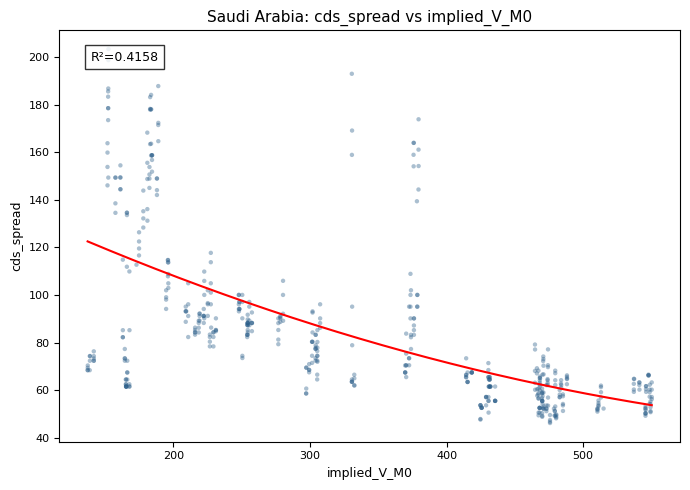

In [37]:
scatter('Saudi Arabia', 'implied_V_M0', 'cds_spread', 'quadratic')

In [522]:
def country_summary(col, models=['M0', 'M1', 'M2'], stat='mean'):
    """Print grouped summary of a variable across models.
    col: base name, e.g. 'DD', 'PD', 'spread_rf', 'implied_V', 'implied_sigma_V'
    stat: 'mean', 'median', 'std', 'min', 'max'
    """
    cols = [f'{col}_{m}' for m in models]
    available = [c for c in cols if c in panel.columns]
    
    agg = panel.groupby(COUNTRY_COL)[available].agg(stat)
    agg['exporter'] = agg.index.isin(EXPORTERS)
    agg = agg.sort_values('exporter', ascending=False)
    
    print(f"\n{stat.upper()} of {col} by country:")
    print(f"{'Country':<20} {'Exporter':>8}", end='')
    for c in available:
        print(f" {c:>18}", end='')
    print()
    print("-" * (30 + 19 * len(available)))
    
    for country, row in agg.iterrows():
        print(f"{country:<20} {'Yes' if row['exporter'] else 'No':>8}", end='')
        for c in available:
            print(f" {row[c]:>18.4f}", end='')
        print()
    
    # Group means
    print("-" * (30 + 19 * len(available)))
    for grp, label in [(True, 'Exporters'), (False, 'Controls')]:
        sub = agg[agg['exporter'] == grp]
        print(f"{label:<20} {'':>8}", end='')
        for c in available:
            print(f" {sub[c].mean():>18.4f}", end='')
        print()

# Usage:
country_summary('DD', stat='min')
# country_summary('PD', stat='median')
# country_summary('spread_rf')
# country_summary('implied_sigma_V', models=['M0', 'M2'])


MIN of DD by country:
Country              Exporter              DD_M0              DD_M1              DD_M2
---------------------------------------------------------------------------------------
Brazil                    Yes             1.4528             1.9733             2.1619
Colombia                  Yes             1.4187             0.1596             1.2248
Egypt                     Yes             0.1882             0.4439             0.4405
Malaysia                  Yes             2.6902            -1.1733             0.7677
Mexico                    Yes             1.8584             0.1327             1.1626
Qatar                     Yes             0.8632             1.2419             1.3643
Saudi Arabia              Yes             4.5561             5.4720             5.5242
UAE (Abu Dhabi)           Yes             2.9558            -1.8406             0.6626
Chile                      No             2.0248             1.6392             2.0261
China              

In [599]:
gamma = 0.15
sigma_V_vals = [0.01, 0.05, 0.10, 0.15, 0.20]
y_vals = [0.05, 0.10, 0.20, 0.30, 0.50]

print(f"{'σ_V':>6} {'|y|':>6} {'γ|y|':>8} {'σ_quad':>10} {'σ_linear':>10} {'Δ_quad':>10} {'Δ_linear':>10}")
print("-" * 70)

for sigma_V in sigma_V_vals:
    for y in y_vals:
        addon      = gamma * abs(y)
        sigma_quad = np.sqrt(sigma_V**2 + addon**2)
        sigma_lin  = sigma_V + addon
        print(f"{sigma_V:>6.2f} {y:>6.2f} {addon:>8.4f} "
              f"{sigma_quad:>10.4f} {sigma_lin:>10.4f} "
              f"{sigma_quad-sigma_V:>10.4f} {sigma_lin-sigma_V:>10.4f}")
    print()

   σ_V    |y|     γ|y|     σ_quad   σ_linear     Δ_quad   Δ_linear
----------------------------------------------------------------------
  0.01   0.05   0.0075     0.0125     0.0175     0.0025     0.0075
  0.01   0.10   0.0150     0.0180     0.0250     0.0080     0.0150
  0.01   0.20   0.0300     0.0316     0.0400     0.0216     0.0300
  0.01   0.30   0.0450     0.0461     0.0550     0.0361     0.0450
  0.01   0.50   0.0750     0.0757     0.0850     0.0657     0.0750

  0.05   0.05   0.0075     0.0506     0.0575     0.0006     0.0075
  0.05   0.10   0.0150     0.0522     0.0650     0.0022     0.0150
  0.05   0.20   0.0300     0.0583     0.0800     0.0083     0.0300
  0.05   0.30   0.0450     0.0673     0.0950     0.0173     0.0450
  0.05   0.50   0.0750     0.0901     0.1250     0.0401     0.0750

  0.10   0.05   0.0075     0.1003     0.1075     0.0003     0.0075
  0.10   0.10   0.0150     0.1011     0.1150     0.0011     0.0150
  0.10   0.20   0.0300     0.1044     0.1300     0.0044 